**Práctica 2. Parte 2.**
**Por Manuela Hernández y Juan Cubides**


**Acercamiento a la base de datos de arritmias cardiacas y comparación estadística** 

**Actividad**

**1.** Exploración y descripción de la base de datos.
Realice una exploración general de la base de datos proporcionada. Identifique y describa:
  •Número total de registros y sujetos.
•Tipos de arritmias o clases disponibles.
•Número de sujetos o registros pertenecientes a cada grupo.
•Número de canales disponibles y sus correspondientes derivaciones.
•Frecuencia de muestreo y duración de los registros.

Presente esta información mediante tablas y, cuando sea pertinente, gráficos que permitan visualizar la distribución de los datos entre las diferentes clases.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

Total de registros: 10646
Rhythm
SB       3889
SR       1826
AFIB     1780
ST       1568
SVT       587
AF        445
SA        399
AT        121
AVNRT      16
AVRT        8
SAAWR       7
Name: count, dtype: int64
Gender
MALE      5956
FEMALE    4690
Name: count, dtype: int64
count    10646.000000
mean        59.186831
std         18.030019
min          4.000000
25%         49.000000
50%         62.000000
75%         72.000000
max         98.000000
Name: PatientAge, dtype: float64


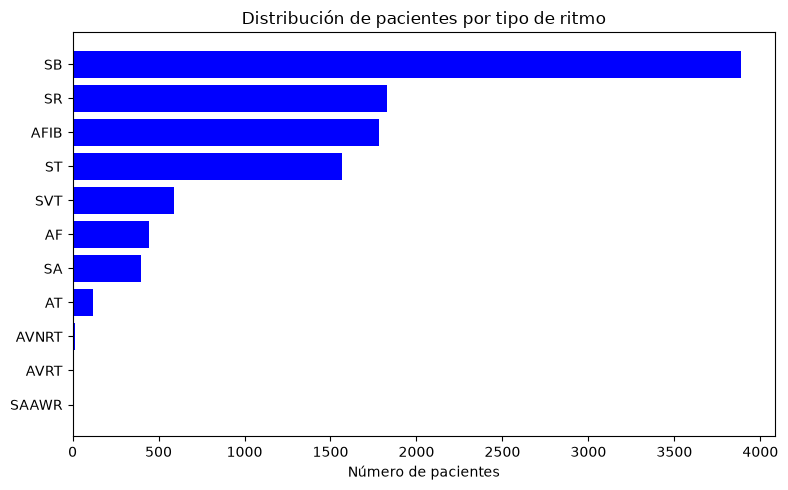

In [ ]:
df = pd.read_excel("Diagnostics.xlsx")

print("Total de registros:", df.shape[0])
print(df['Rhythm'].value_counts())
print(df['Gender'].value_counts())
print(df['PatientAge'].describe())

conteo = df['Rhythm'].value_counts().sort_values()
plt.figure(figsize=(8,5))
plt.barh(conteo.index, conteo.values, color= "b")
plt.xlabel("Número de pacientes")
plt.title("Distribución de pacientes por tipo de ritmo")
plt.tight_layout()
plt.show()

**2.** Visualización y caracterización de las señales. Seleccione dos registros de dos tipos tipo de arritmia. Realice una breve consulta de esas dos arritmias y realice una visualización de las señales ECG. Analice los aspectos como la morfología, amplitud, frecuencia cardíaca y regularidad de los latidos.

**Fibrilación Auricular (AFIB):** Es la arritmia sostenida más común en la práctica clínica. Se produce por actividad eléctrica caótica y desorganizada en las aurículas, lo que hace que desaparezca la onda P (se reemplaza por ondulaciones irregulares llamadas "ondas f") y que los intervalos RR sean irregularmente irregulares (no hay un patrón fijo de distancia entre latidos). La frecuencia ventricular puede variar mucho de un latido a otro y de un paciente a otro, dependiendo de cuántos de esos impulsos caóticos logran pasar al ventrículo.

**Taquicardia Sinusal (ST):** Es un ritmo que sigue originándose de forma normal en el nodo sinoauricular (SA) — o sea, mantiene la secuencia eléctrica correcta del corazón: onda P normal antes de cada QRS, con la misma morfología de siempre — pero ocurre a una frecuencia más alta de lo normal, típicamente por encima de 100 lpm (en los datos que tenemos, el promedio es 112 lpm). Es la respuesta normal del corazón ante situaciones como ejercicio, fiebre, ansiedad, dolor, anemia, deshidratación, o algunas condiciones médicas — es decir, muchas veces es una respuesta fisiológica adecuada del cuerpo y no necesariamente indica una enfermedad del corazón en sí.

In [ ]:
#Punto 1 - verificar frecuencia de muestreo con más de un archivo de señal
señal_afib = pd.read_csv("MUSE_20180114_135033_25000.csv", header=None)
señal_st   = pd.read_csv("MUSE_20180112_134129_67000.csv", header=None)

duracion_seg = 10  # documentado por el dataset

for nombre, señal in zip(["AFIB", "ST"], [señal_afib, señal_st]):
    num_muestras = señal.shape[0]
    num_canales  = señal.shape[1]
    fs = num_muestras / duracion_seg
    print(f"{nombre}: muestras = {num_muestras}, canales = {num_canales}, fs = {fs} Hz")

AFIB: muestras = 5000, canales = 12, fs = 500.0 Hz
ST: muestras = 5000, canales = 12, fs = 500.0 Hz


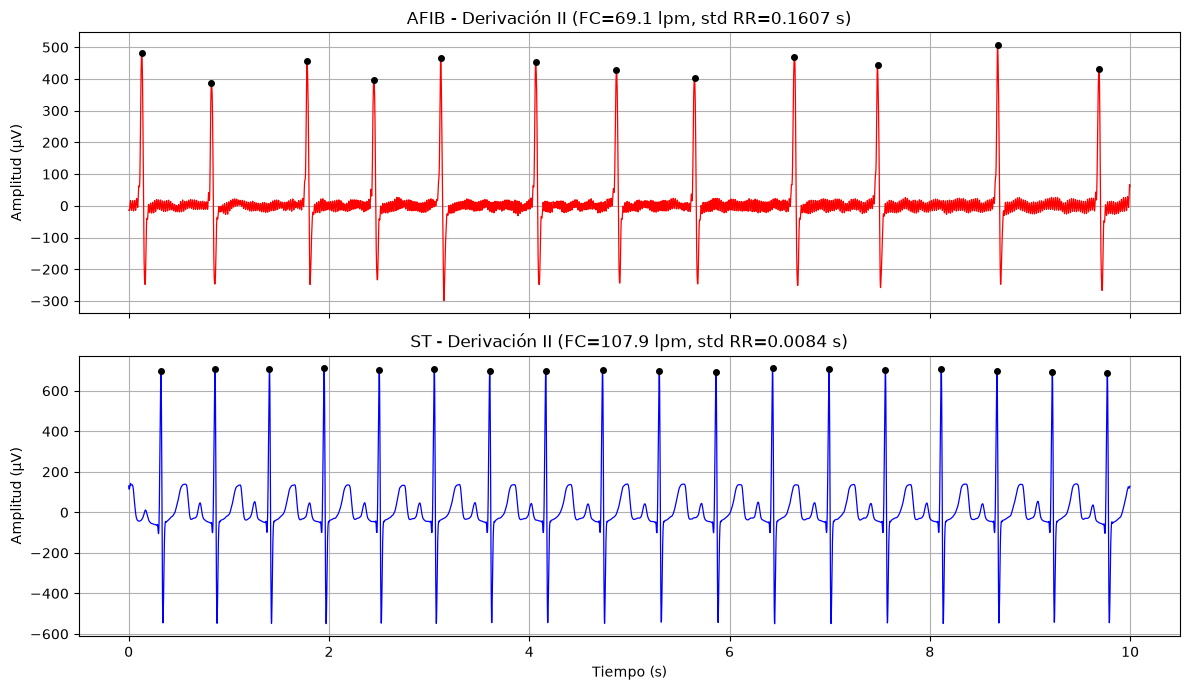

In [ ]:

fs = 500

def cargar_señal(ruta_archivo, derivacion=1):
    return pd.read_csv(ruta_archivo, header=None)[derivacion].values

def analizar_ritmo(señal):
    picos, _ = find_peaks(señal, distance=int(fs*0.3), prominence=(señal.max()-señal.min())*0.3)
    rr = np.diff(picos) / fs
    return picos, 60/np.mean(rr), np.std(rr)

def graficar_comparacion(señales, nombres, colores):
    vector_tiempo = np.arange(len(señales[0])) / fs
    fig, axes = plt.subplots(len(señales), 1, figsize=(12,7), sharex=True)
    
    for ax, señal, nombre, color in zip(axes, señales, nombres, colores):
        picos, fc, std_rr = analizar_ritmo(señal)
        ax.plot(vector_tiempo, señal, color, linewidth=0.9)
        ax.plot(vector_tiempo[picos], señal[picos], 'ko', markersize=4)
        ax.set_title(f"{nombre} - Derivación II (FC={fc:.1f} lpm, std RR={std_rr:.4f} s)")
        ax.set_ylabel("Amplitud (µV)")
        ax.grid(True)
    
    axes[-1].set_xlabel("Tiempo (s)")
    plt.tight_layout()
    plt.show()


señal_afib = cargar_señal("MUSE_20180114_135033_25000.csv")
señal_st   = cargar_señal("MUSE_20180112_134129_67000.csv")

graficar_comparacion([señal_afib, señal_st], ["AFIB", "ST"], ["r-", "b-"])

In [ ]:
from scipy import stats

# Extracción de características por latido para cada paciente
def extraer_features_por_latido(señal, fs):
    """
    A partir de los picos R detectados (misma lógica de analizar_ritmo),
    calcula por cada ciclo cardiaco: RMS, media, desviación estándar,
    máximo, mínimo y frecuencia cardiaca instantánea (bpm).
    """
    picos, _, _ = analizar_ritmo(señal)
    feats = {'rms': [], 'media': [], 'std': [], 'max': [], 'min': [], 'hr_bpm': []}

    for i in range(len(picos) - 1):
        ciclo = señal[picos[i]:picos[i+1]]
        if len(ciclo) < 5:
            continue
        rr = (picos[i+1] - picos[i]) / fs
        feats['rms'].append(np.sqrt(np.mean(ciclo**2)))
        feats['media'].append(np.mean(ciclo))
        feats['std'].append(np.std(ciclo))
        feats['max'].append(np.max(ciclo))
        feats['min'].append(np.min(ciclo))
        feats['hr_bpm'].append(60 / rr)

    return pd.DataFrame(feats)

# Se recargan explícitamente como vector 1-D (derivación II) para evitar
# que queden sobrescritas si las celdas se ejecutan fuera de orden.
señal_afib = cargar_señal("MUSE_20180114_135033_25000.csv")
señal_st   = cargar_señal("MUSE_20180112_134129_67000.csv")

df_afib = extraer_features_por_latido(señal_afib, fs)
df_st   = extraer_features_por_latido(señal_st, fs)

df_afib['grupo'] = 'AFIB'
df_st['grupo']   = 'ST'
df_todos = pd.concat([df_afib, df_st], ignore_index=True)

print(f"Latidos detectados -> AFIB: {len(df_afib)}, ST: {len(df_st)}")
df_todos.head()

Latidos detectados -> AFIB: 11, ST: 17


,rms,media,std,max,min,hr_bpm,grupo
0,82.658801,6.619252,82.393342,480.91,-248.26,86.206897,AFIB
1,70.839531,5.161001,70.651279,454.06,-246.67,62.761506,AFIB
2,82.941814,8.661193,82.488353,455.76,-248.16,90.090090,AFIB
3,80.771810,8.227813,80.351655,450.87,-233.34,89.820359,AFIB
4,72.950066,3.387155,72.871388,464.94,-298.66,63.291139,AFIB


In [ ]:
import seaborn as sns

# Tabla resumen (media, desviación estándar, máximo, mínimo)
resumen = df_todos.groupby('grupo')[['rms','media','std','max','min','hr_bpm']].agg(['mean','std','max','min'])
resumen

rms                                       media            \
             mean       std         max         min      mean       std   
grupo                                                                     
AFIB    76.225480  5.881841   82.941814   63.799827  6.510207  1.690778   
ST     144.766631  2.810853  148.640969  139.392628  9.247314  1.675702   

                                  std            ...     max          \
             max       min       mean       std  ...     max     min   
grupo                                            ...                   
AFIB    8.661193  3.387155   75.93574  5.797606  ...  506.70  427.64   
ST     11.840484  5.167870  144.46341  2.723501  ...  710.97  693.78   

              min                                 hr_bpm             \
             mean        std     max     min        mean        std   
grupo                                                                 
AFIB  -251.783636  16.591685 -233.34 -298.66   71.392378  13.480028   
ST    -546.408235   2.385580 -541.91 -549.70  107.961314   1.689274   

                               
              max         min  
grupo                          
AFIB    90.090090   50.083472  
ST     111.111111  105.633803  

[2 rows x 24 columns]

In [ ]:
variables = ['rms', 'media', 'std', 'max', 'min', 'hr_bpm']

# Boxplots comparativos
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, var in zip(axes.flat, variables):
    sns.boxplot(data=df_todos, x='grupo', y=var, hue='grupo', ax=ax, palette=['red','blue'], legend=False)
    ax.set_title(var)
plt.suptitle("Comparación AFIB vs ST - Boxplots por variable")
plt.tight_layout()
plt.show()

# Diagramas de densidad
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, var in zip(axes.flat, variables):
    sns.kdeplot(data=df_todos, x=var, hue='grupo', ax=ax, fill=True, palette=['red','blue'])
    ax.set_title(var)
plt.suptitle("Comparación AFIB vs ST - Densidad por variable")
plt.tight_layout()
plt.show()